# **Brain Tumor MRI Image Classification - EDA**

##### **Project Type**    - Classification (Medical Imaging / Computer Vision) - EDA notebook
##### **Contribution**    - Individual
##### **Team Member 1 -** *Sita Bharatula*

# **Project Summary -**

This project builds a deep-learning system that classifies brain MRI slices into four categories - **glioma, meningioma, pituitary tumour and no tumour** - and serves predictions through a Streamlit web app. Two model families are compared: a custom CNN trained from scratch (convolution blocks with batch-normalisation, max-pooling and dropout) and transfer-learning models (ResNet50, MobileNetV2, InceptionV3, EfficientNetB0) initialised with ImageNet weights, with a new dense head and optional fine-tuning of the top layers.

This notebook covers the first stage of the workflow - understanding the dataset - and is fully executable top to bottom. The dataset has 2,443 JPEG images already divided into train (1,695), validation (502) and test (246) folders. All images are 640x640 RGB, so no resolution clean-up is needed; they will be resized to 224x224 and scaled to 0-1 (or backbone-specific scaling) for modelling. There are no corrupt files, no exact byte-level duplicates and no missing labels.

The EDA surfaced several findings that directly shape the modelling plan. (1) **Moderate class imbalance**: glioma is the largest class (about a third of the training set) while no-tumour is the smallest (about 20%). The ratio is below 2:1, so class weights plus macro-averaged metrics are enough; resampling is not required. (2) **Strong brightness differences between classes**: the mean grey level is about 28/255 for glioma versus about 60/255 for no-tumour, and file sizes follow the same ordering. This is probably an acquisition artefact (different scanners, sequences or windowing) rather than anatomy, and a network could exploit it as a shortcut. We therefore include brightness and contrast jitter in augmentation and recommend checking Grad-CAM maps and per-class errors. (3) **Possible split leakage**: the filenames show that some source images appear in more than one split as different augmented copies (164 source-image names occur in two splits, with a median pixel correlation of about 0.88 between the copies). Test accuracy may therefore be somewhat optimistic, and we report it with that caveat. (4) The intensity features are highly inter-correlated (mean brightness vs. 95th-percentile intensity r = 0.84), so they carry largely redundant information.

The modelling plan that follows from this: normalise and resize to 224x224; augment with flips, rotation, zoom, shifts, contrast and brightness; train with EarlyStopping, ModelCheckpoint and LR scheduling; evaluate with accuracy, macro precision/recall/F1 and confusion matrices; compare models on accuracy, size and latency; and deploy the best trade-off model in Streamlit with confidence scores and a low-confidence warning. Because this is a medical application, recall on tumour classes and the cost of missing a tumour matter more than headline accuracy, and the tool is positioned as decision support for radiologists rather than a replacement.

*Final model metrics are reported in `reports/model_comparison.csv` after running `src/train.py` and `src/evaluate.py`.*

# **GitHub Link -**

*https://github.com/maha2806/Brain-Tumor-MRI.git*

# **Problem Statement**

**Classify brain MRI images into glioma, meningioma, pituitary tumour or no tumour using a custom CNN and transfer-learning models, compare them, and deploy the best one in a Streamlit app that returns the predicted tumour type with a confidence score.**

#### **Define Your Business Objective?**

Give radiologists and clinics a fast, consistent **second-opinion / triage tool**: flag likely-tumour scans for priority review, reduce turnaround time, and support remote or under-resourced settings. Success means high recall on tumour classes (few missed tumours), reliable calibrated confidence scores, and a model small and fast enough to deploy cheaply.

# **General Guidelines** : -  
1. Well-structured, formatted, and commented code is required.
2. Exception handling and deployment-ready code (the whole notebook executes in one go without errors) earn additional credit.
3. Every logic block has comments.
4. Any number of charts may be added.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [5]:
# Import Libraries
import os, re, glob, hashlib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
SEED = 42
np.random.seed(SEED)

### Dataset Loading

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from pathlib import Path

# Possible locations
CANDIDATES = [
    Path("/content/drive/MyDrive/Tumour"),
    Path("/content/drive/MyDrive/tumour"),
]

DATA_DIR = None

for path in CANDIDATES:
    if (
        (path / "train").exists()
        and (path / "valid").exists()
        and (path / "test").exists()
    ):
        DATA_DIR = path
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Tumour dataset not found in My Drive. "
        "Make sure the Tumour folder/shortcut is inside My Drive."
    )

print("Using dataset at:")
print(DATA_DIR)

Using dataset at:
/content/drive/MyDrive/Tumour


In [7]:
import shutil
from pathlib import Path

SOURCE = Path("/content/drive/MyDrive/Tumour")
LOCAL = Path("/content/Tumour")

if not LOCAL.exists():
    print("Copying dataset from Google Drive to Colab...")
    shutil.copytree(SOURCE, LOCAL)
    print("Dataset copied successfully!")
else:
    print("Dataset already exists in Colab.")

DATA_DIR = LOCAL

print("Using dataset at:", DATA_DIR)

Copying dataset from Google Drive to Colab...
Dataset copied successfully!
Using dataset at: /content/Tumour


In [8]:
from PIL import Image
import numpy as np
import pandas as pd
import re

THUMB = 64

rows = []
corrupt = []

for path in sorted(DATA_DIR.glob("*/*/*")):

    if path.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
        continue

    try:
        with Image.open(path) as im:

            w, h = im.size
            mode = im.mode

            g = np.asarray(
                im.convert("L").resize((THUMB, THUMB)),
                dtype=np.float32
            )

        rows.append({
            "path": str(path),
            "split": path.parts[-3],
            "label": path.parts[-2],
            "width": w,
            "height": h,
            "mode": mode,
            "file_kb": path.stat().st_size / 1024,
            "mean_intensity": g.mean(),
            "std_intensity": g.std(),
            "p95_intensity": np.percentile(g, 95),
            "fg_fraction": (g > 30).mean(),
            "source_id": re.sub(
                r"_jpg\.rf\..*",
                "",
                path.name
            )
        })

    except Exception as e:
        corrupt.append((str(path), str(e)))

df = pd.DataFrame(rows)

print(f"Loaded {len(df)} images")
print(f"Unreadable images: {len(corrupt)}")

print("\nImages per split:")
print(df["split"].value_counts())

print("\nImages per label:")
print(df["label"].value_counts())

df.head()

Loaded 2443 images
Unreadable images: 0

Images per split:
split
train    1695
valid     502
test      246
Name: count, dtype: int64

Images per label:
label
glioma        805
pituitary     610
meningioma    545
no_tumor      483
Name: count, dtype: int64


,path,split,label,width,height,mode,file_kb,mean_intensity,std_intensity,p95_intensity,fg_fraction,source_id
0,/content/Tumour/test/glioma/Tr-gl_0016_jpg.rf....,test,glioma,640,640,RGB,28.125000,33.614746,38.825111,108.00,0.435547,Tr-gl_0016
1,/content/Tumour/test/glioma/Tr-gl_0018_jpg.rf....,test,glioma,640,640,RGB,26.443359,31.054932,33.046158,93.25,0.458984,Tr-gl_0018
2,/content/Tumour/test/glioma/Tr-gl_0028_jpg.rf....,test,glioma,640,640,RGB,31.201172,37.677734,36.840572,103.25,0.514648,Tr-gl_0028
3,/content/Tumour/test/glioma/Tr-gl_0032_jpg.rf....,test,glioma,640,640,RGB,31.427734,48.366699,46.867123,127.00,0.521240,Tr-gl_0032
4,/content/Tumour/test/glioma/Tr-gl_0035_jpg.rf....,test,glioma,640,640,RGB,27.150391,33.021240,38.249737,101.00,0.441895,Tr-gl_0035


In [10]:
hashlib.md5(path.read_bytes())

<md5 _hashlib.HASH object @ 0x7df58910e130>

### Dataset First View

In [16]:
# Dataset First Look
# Since 'md5' is not a column in df, we display df directly. We can safely drop it if it exists.
df.drop(columns=['md5'], errors='ignore').head()

,path,split,label,width,height,mode,file_kb,mean_intensity,std_intensity,p95_intensity,fg_fraction,source_id
0,/content/Tumour/test/glioma/Tr-gl_0016_jpg.rf....,test,glioma,640,640,RGB,28.125000,33.614746,38.825111,108.00,0.435547,Tr-gl_0016
1,/content/Tumour/test/glioma/Tr-gl_0018_jpg.rf....,test,glioma,640,640,RGB,26.443359,31.054932,33.046158,93.25,0.458984,Tr-gl_0018
2,/content/Tumour/test/glioma/Tr-gl_0028_jpg.rf....,test,glioma,640,640,RGB,31.201172,37.677734,36.840572,103.25,0.514648,Tr-gl_0028
3,/content/Tumour/test/glioma/Tr-gl_0032_jpg.rf....,test,glioma,640,640,RGB,31.427734,48.366699,46.867123,127.00,0.521240,Tr-gl_0032
4,/content/Tumour/test/glioma/Tr-gl_0035_jpg.rf....,test,glioma,640,640,RGB,27.150391,33.021240,38.249737,101.00,0.441895,Tr-gl_0035


### Dataset Rows & Columns count

In [13]:
# Dataset Rows & Columns count
print('Rows   :', df.shape[0])
print('Columns:', df.shape[1])

Rows   : 2443
Columns: 12


### Dataset Information

In [14]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443 entries, 0 to 2442
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   path            2443 non-null   object 
 1   split           2443 non-null   object 
 2   label           2443 non-null   object 
 3   width           2443 non-null   int64  
 4   height          2443 non-null   int64  
 5   mode            2443 non-null   object 
 6   file_kb         2443 non-null   float64
 7   mean_intensity  2443 non-null   float32
 8   std_intensity   2443 non-null   float32
 9   p95_intensity   2443 non-null   float32
 10  fg_fraction     2443 non-null   float64
 11  source_id       2443 non-null   object 
dtypes: float32(3), float64(2), int64(2), object(5)
memory usage: 200.5+ KB


#### Duplicate Values

In [17]:
# Calculate MD5 hashes on-the-fly and add them as a column in df
import hashlib

def get_md5(path_str):
    try:
        with open(path_str, "rb") as f:
            return hashlib.md5(f.read()).hexdigest()
    except Exception:
        return None

df['md5'] = df['path'].apply(get_md5)

# Exact (byte-identical) duplicates, and near-duplicates inferred from shared source ids
print("Exact duplicate files:", df.duplicated(subset='md5').sum())
split_per_source = df.groupby('source_id')['split'].nunique()
print("Source ids that appear in more than one split:", (split_per_source > 1).sum(),
      "of", df['source_id'].nunique())

Exact duplicate files: 0
Source ids that appear in more than one split: 164 of 2091


#### Missing Values/Null Values

In [18]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
path,0
split,0
label,0
width,0
height,0
mode,0
file_kb,0
mean_intensity,0
std_intensity,0
p95_intensity,0


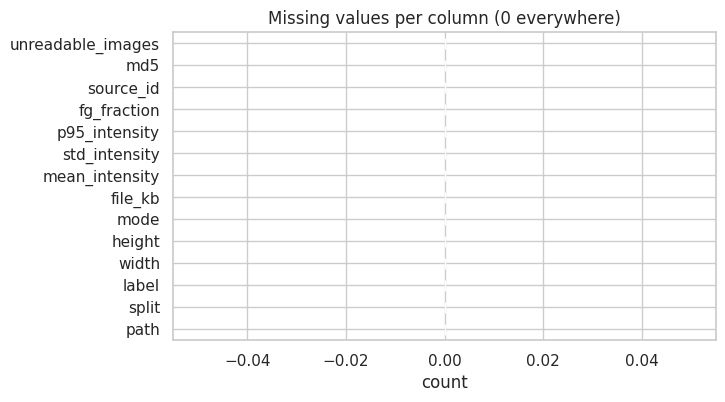

In [19]:
# Visualizing the missing values (+ unreadable images)
miss = df.isnull().sum()
miss['unreadable_images'] = len(corrupt)
ax = miss.plot(kind='barh', figsize=(7, 4), color='steelblue')
ax.set_title('Missing values per column (0 everywhere)'); ax.set_xlabel('count'); plt.show()

### What did you know about your dataset?

The dataset is an **image** dataset (not tabular): 2,443 JPEGs in `train/valid/test` folders, with the folder name as the label across **4 classes** (glioma, meningioma, no_tumor, pituitary). Every image is 640x640 RGB, there are no unreadable files, no missing labels and no byte-identical duplicates. Two issues deserve attention: classes differ markedly in brightness (a possible shortcut), and some source images appear in several splits as augmented copies (possible train/test leakage). Tabular features were derived from each image so that standard EDA can be applied.

## ***2. Understanding Your Variables***

In [20]:
# Dataset Columns
print(list(df.columns))

['path', 'split', 'label', 'width', 'height', 'mode', 'file_kb', 'mean_intensity', 'std_intensity', 'p95_intensity', 'fg_fraction', 'source_id', 'md5']


In [21]:
# Dataset Describe
df.drop(columns=['md5']).describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
width,2443.0,640.00,0.00,640.00,640.00,640.00,640.00,640.00
height,2443.0,640.00,0.00,640.00,640.00,640.00,640.00,640.00
file_kb,2443.0,31.17,9.09,16.44,24.05,30.01,36.71,121.68
mean_intensity,2443.0,43.78,18.62,9.78,29.55,40.08,53.14,137.79
std_intensity,2443.0,41.87,10.95,20.88,34.78,39.59,45.54,88.96
p95_intensity,2443.0,119.59,36.15,50.00,97.00,114.00,132.00,255.00
fg_fraction,2443.0,0.51,0.15,0.13,0.40,0.48,0.62,1.00


### Variables Description

| Variable | Meaning |
|---|---|
| `path` | Image file location |
| `split` | train / valid / test folder |
| `label` | Target class: glioma, meningioma, no_tumor, pituitary |
| `width`, `height`, `mode` | Image resolution and colour mode (all 640x640 RGB) |
| `file_kb` | JPEG size in KB (proxy for image detail/brightness) |
| `mean_intensity`, `std_intensity` | Mean and spread of grey levels (0-255) on a 64x64 thumbnail |
| `p95_intensity` | 95th percentile grey level (brightness of the bright structures) |
| `fg_fraction` | Share of pixels brighter than 30 (rough proxy for how much of the frame is non-black) |
| `source_id` | Original image name without the augmentation hash; used for leakage checks |
| `md5` | File hash for exact-duplicate detection |

### Check Unique Values for each variable.

In [22]:
# Check Unique Values for each variable.
df.drop(columns=['md5','path']).nunique()

,0
split,3
label,4
width,1
height,1
mode,1
file_kb,2340
mean_intensity,2367
std_intensity,2442
p95_intensity,306
fg_fraction,1333


## 3. ***Data Wrangling***

### Data Wrangling Code

In [23]:
# Write your code to make your dataset analysis ready.
CLASS_NAMES = sorted(df['label'].unique())                 # alphabetical = Keras folder order
df['label_id'] = df['label'].map({c: i for i, c in enumerate(CLASS_NAMES)})
df['split'] = pd.Categorical(df['split'], ['train', 'valid', 'test'], ordered=True)

# Flag images whose source id also appears in a different split (potential leakage)
n_splits = df.groupby('source_id')['split'].transform('nunique')
df['cross_split_source'] = n_splits > 1

print("Classes:", CLASS_NAMES)
print("Images flagged as cross-split copies:", int(df['cross_split_source'].sum()))
print(df.groupby('split', observed=True)['label'].value_counts().unstack())

Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Images flagged as cross-split copies: 328
label  glioma  meningioma  no_tumor  pituitary
split                                         
train     564         358       335        438
valid     161         124        99        118
test       80          63        49         54


### What all manipulations have you done and insights you found?

I scanned the folders into a metadata table, derived per-image brightness/contrast/size features from a 64x64 grey thumbnail, encoded labels alphabetically (matching Keras' folder ordering), ordered the splits, and flagged images whose source id appears in more than one split. Findings: images are uniform in size, nothing is missing or corrupt, the class mix is similar across splits (glioma 32-33%, no_tumor about 20%), and 164 source names recur across splits, which is a leakage risk to disclose when reporting test results.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Class distribution per split

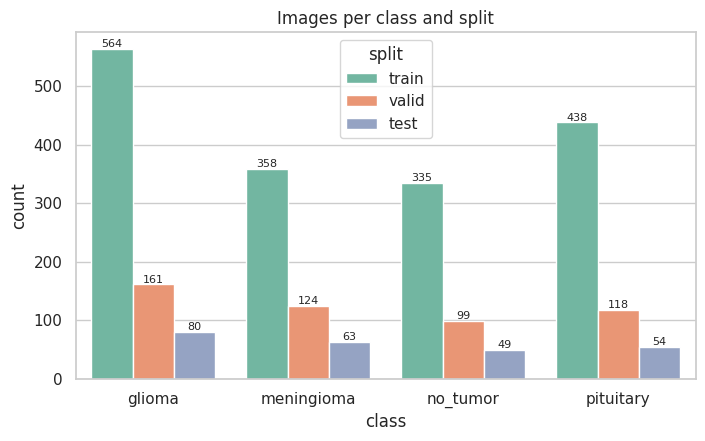

In [24]:
# Chart - 1 visualization code
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.countplot(data=df, x='label', hue='split', order=CLASS_NAMES, ax=ax)
for c in ax.containers: ax.bar_label(c, fontsize=8)
ax.set_title('Images per class and split'); ax.set_xlabel('class'); plt.show()

##### 1. Why did you pick the specific chart?
A grouped bar chart compares counts across categories and splits at a glance, which is exactly what a class-imbalance check needs.

##### 2. What is/are the insight(s) found from the chart?
Glioma is the largest class in every split (564 train images) and no_tumor the smallest (335). The imbalance is mild (about 1.7:1).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
Positive: no resampling is needed - balanced class weights and macro-F1 suffice. Risk: an unweighted model would favour glioma and could under-detect healthy scans, so metrics must be reported per class.

#### Chart - 2 - Class share by split

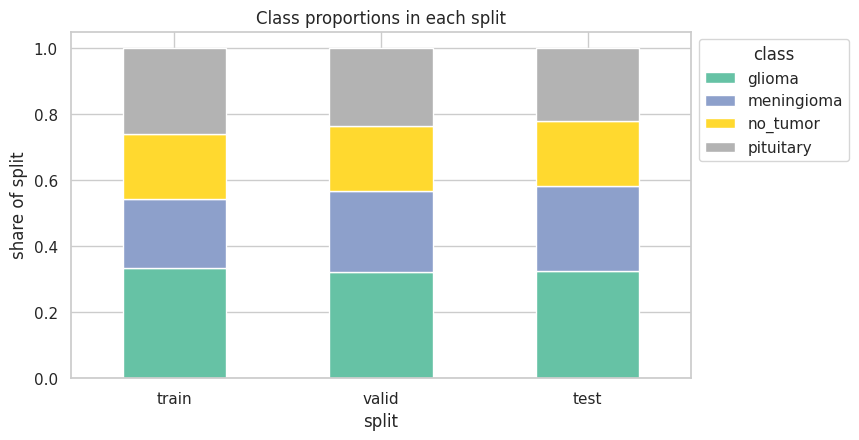

In [25]:
# Chart - 2 visualization code
share = pd.crosstab(df['split'], df['label'], normalize='index')
ax = share.plot(kind='bar', stacked=True, figsize=(8, 4.5), colormap='Set2')
ax.set_ylabel('share of split'); ax.set_title('Class proportions in each split'); ax.legend(title='class', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0); plt.show()

##### 1. Why did you pick the specific chart?
100%-stacked bars show whether each split has the same class mix, independent of split size.

##### 2. What is/are the insight(s) found from the chart?
Proportions are broadly similar (glioma 32-33%, no_tumor about 20%), with meningioma over-represented in valid/test (about 25%) relative to train (about 21%).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
Positive: validation and test estimates are representative. The small meningioma shift means the test set is slightly easier/harder per class, so I will compare per-class recall, not just accuracy.

#### Chart - 3 - Sample MRI images per class

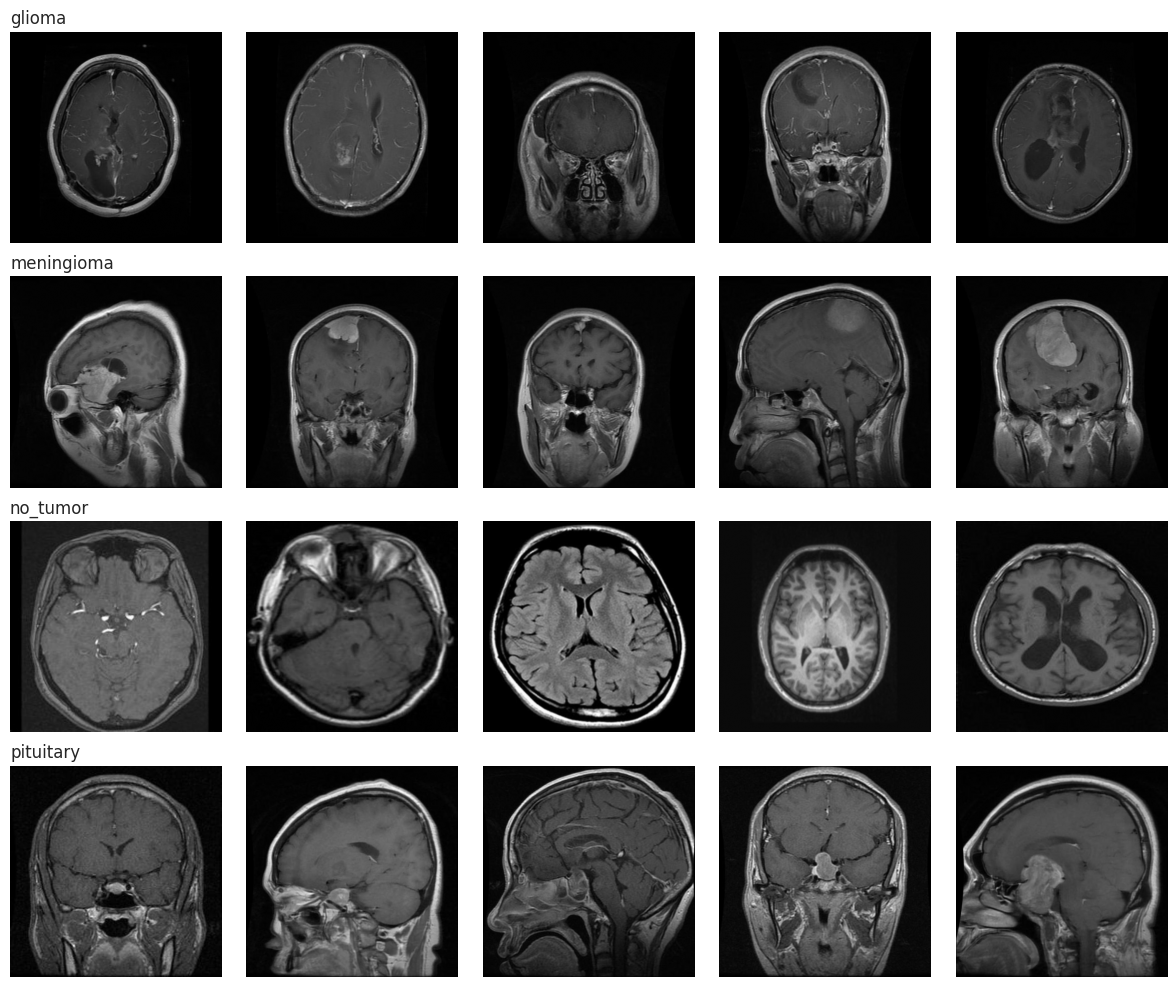

In [26]:
# Chart - 3 visualization code
fig, axes = plt.subplots(len(CLASS_NAMES), 5, figsize=(12, 10))
rng = np.random.default_rng(SEED)
for r, cls in enumerate(CLASS_NAMES):
    picks = rng.choice(df.loc[df.label == cls, 'path'].values, 5, replace=False)
    for c, p in enumerate(picks):
        axes[r, c].imshow(Image.open(p).convert('L'), cmap='gray'); axes[r, c].axis('off')
    axes[r, 0].set_title(cls, loc='left', fontsize=12)
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?
For image data the most direct EDA is looking at the images: it reveals orientation, cropping, contrast and whether classes look separable.

##### 2. What is/are the insight(s) found from the chart?
Slices come from different planes (axial, sagittal, coronal) and differ in zoom, contrast and cropping. Glioma images look darker overall; tumour appearance varies a lot within a class.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
Positive: variation in plane and zoom argues for rotation/flip/zoom augmentation and for a model that generalises rather than memorises. Negative: high within-class variability means small data can overfit, so regularisation (dropout, BN, early stopping) is important.

#### Chart - 4 - Image resolution consistency

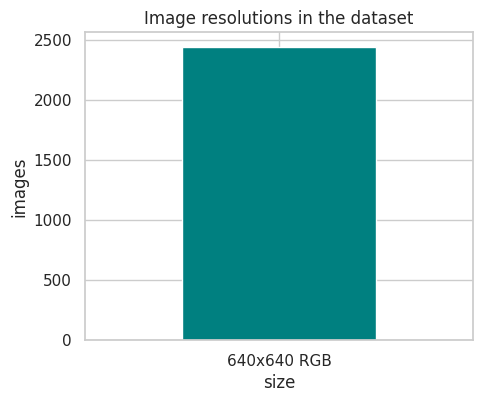

In [27]:
# Chart - 4 visualization code
res = df.assign(size=df.width.astype(str) + 'x' + df.height.astype(str) + ' ' + df['mode'])
ax = res['size'].value_counts().plot(kind='bar', figsize=(5, 4), color='teal')
ax.set_title('Image resolutions in the dataset'); ax.set_ylabel('images'); plt.xticks(rotation=0); plt.show()

##### 1. Why did you pick the specific chart?
A simple bar chart of unique resolutions answers the consistency question directly.

##### 2. What is/are the insight(s) found from the chart?
All 2,443 images are 640x640 RGB - there is a single resolution.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
Positive: preprocessing is just one resize to 224x224 with no padding/cropping heuristics, and no aspect-ratio distortion. Downscaling 640 to 224 loses fine detail, which could matter for small pituitary tumours - a larger input size is a possible later experiment.

#### Chart - 5 - Mean intensity by class

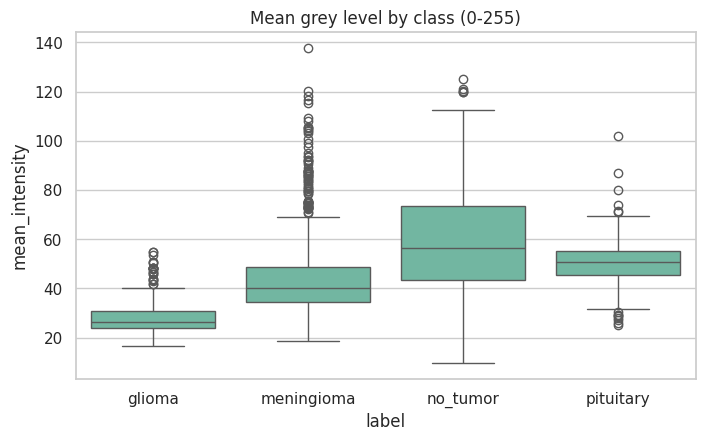

                 mean        std
label                           
glioma      27.799999   6.100000
meningioma  45.900002  18.700001
no_tumor    59.900002  21.600000
pituitary   50.299999   8.500000


In [28]:
# Chart - 5 visualization code
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df, x='label', y='mean_intensity', order=CLASS_NAMES, ax=ax)
ax.set_title('Mean grey level by class (0-255)'); plt.show()
print(df.groupby('label')['mean_intensity'].agg(['mean', 'std']).round(1))

##### 1. Why did you pick the specific chart?
A box plot compares distributions (median, spread, outliers) across categories for a numeric feature.

##### 2. What is/are the insight(s) found from the chart?
Glioma images are much darker (mean about 28) than meningioma (about 46), pituitary (about 50) and no_tumor (about 60), and glioma is also the most tightly clustered (std about 6).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
Risk: brightness alone partially separates classes, which is likely an acquisition artefact. A model could reach decent accuracy by shortcut and then fail on scans from another hospital. Mitigation: brightness/contrast augmentation, Grad-CAM inspection and external validation before any clinical claim.

#### Chart - 6 - Contrast (std of intensity) distribution

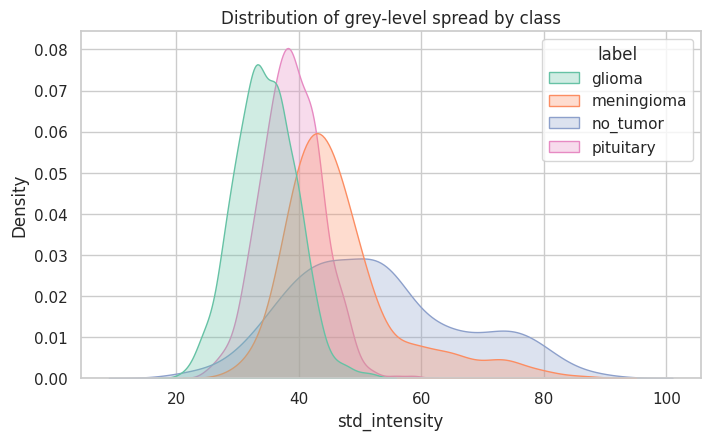

In [29]:
# Chart - 6 visualization code
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.kdeplot(data=df, x='std_intensity', hue='label', hue_order=CLASS_NAMES, fill=True, alpha=.3, common_norm=False, ax=ax)
ax.set_title('Distribution of grey-level spread by class'); plt.show()

##### 1. Why did you pick the specific chart?
Density plots show the full shape of each class distribution and overlap between classes, which box plots can hide.

##### 2. What is/are the insight(s) found from the chart?
Glioma and pituitary have narrow, low-contrast distributions (mean std about 35 and 39) while no_tumor and meningioma are wider and shifted higher (about 53 and 47), with heavy overlap between meningioma and no_tumor.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
Positive: overlap means contrast is not a clean shortcut for every pair, so the network must learn real structure. Contrast jitter in augmentation will further reduce reliance on it.

#### Chart - 7 - Average image per class

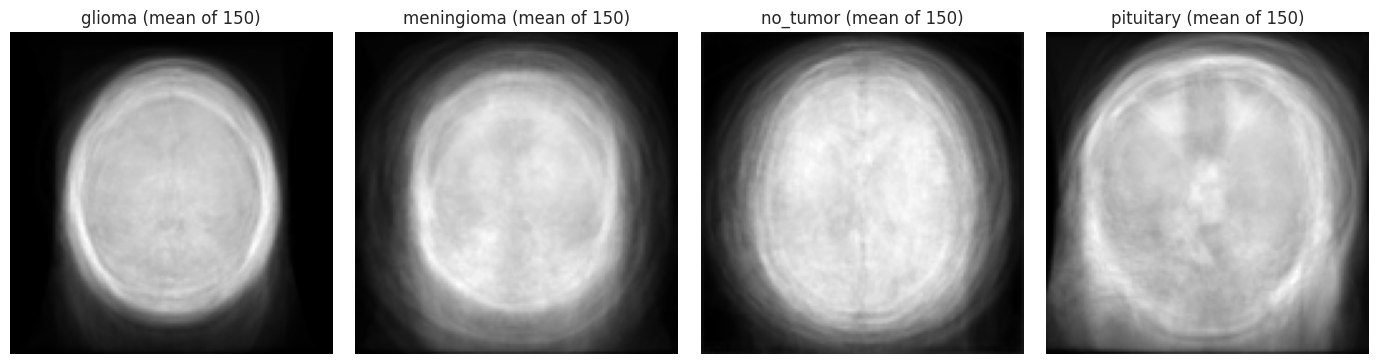

In [30]:
# Chart - 7 visualization code
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(14, 3.6))
for ax, cls in zip(axes, CLASS_NAMES):
    paths = df.loc[df.label == cls, 'path'].sample(min(150, (df.label == cls).sum()), random_state=SEED)
    stack = np.mean([np.asarray(Image.open(p).convert('L').resize((128, 128)), float) for p in paths], axis=0)
    ax.imshow(stack, cmap='gray'); ax.set_title(f'{cls} (mean of {len(paths)})'); ax.axis('off')
plt.tight_layout(); plt.show()

##### 1. Why did you pick the specific chart?
Averaging many images per class shows the typical layout/orientation and where brightness is concentrated.

##### 2. What is/are the insight(s) found from the chart?
The average images are blurry brain-shaped blobs with little class-specific structure, but they differ in overall brightness and in how much of the frame the head fills.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
Positive: no single canonical position identifies a class, so a CNN will need to learn local texture/shape features. Negative: differences in framing between classes are another potential shortcut to watch for.

#### Chart - 8 - Pixel intensity histograms

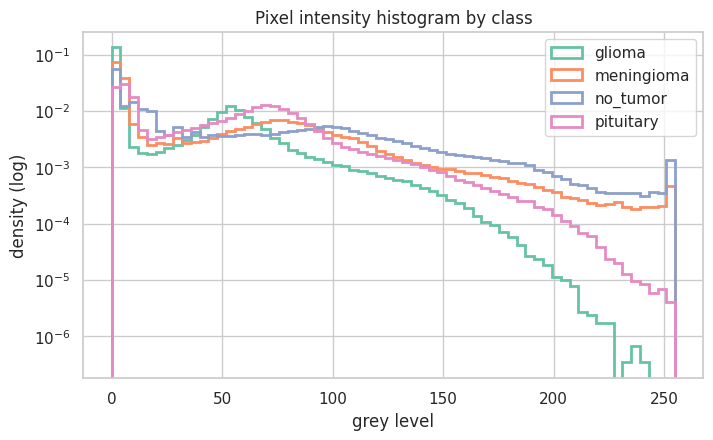

In [31]:
# Chart - 8 visualization code
fig, ax = plt.subplots(figsize=(8, 4.5))
for cls in CLASS_NAMES:
    paths = df.loc[df.label == cls, 'path'].sample(min(80, (df.label == cls).sum()), random_state=SEED)
    px = np.concatenate([np.asarray(Image.open(p).convert('L').resize((96, 96))).ravel() for p in paths])
    ax.hist(px, bins=64, range=(0, 255), density=True, histtype='step', linewidth=2, label=cls)
ax.set_yscale('log'); ax.set_xlabel('grey level'); ax.set_ylabel('density (log)'); ax.legend()
ax.set_title('Pixel intensity histogram by class'); plt.show()

##### 1. Why did you pick the specific chart?
Overlaid histograms (log scale) show where each class puts its pixels - background vs tissue vs bright regions.

##### 2. What is/are the insight(s) found from the chart?
All classes have a large spike at 0 (black background); beyond that, glioma's mass drops off sooner while no_tumor keeps more mid/high intensities.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
Positive: confirms that normalising to 0-1 is sensible and that the background is largely uninformative. It also supports the brightness-augmentation decision.

#### Chart - 9 - JPEG file size by class

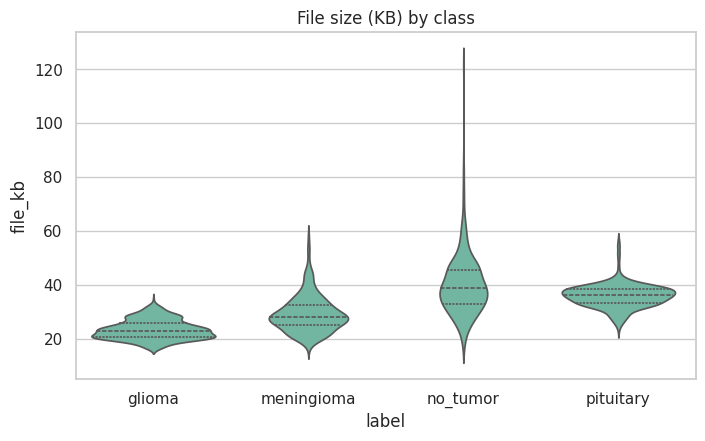

In [32]:
# Chart - 9 visualization code
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.violinplot(data=df, x='label', y='file_kb', order=CLASS_NAMES, inner='quartile', ax=ax)
ax.set_title('File size (KB) by class'); plt.show()

##### 1. Why did you pick the specific chart?
A violin plot adds distribution shape to the quartiles; file size is a cheap proxy for image detail and brightness.

##### 2. What is/are the insight(s) found from the chart?
File size follows the brightness ordering (glioma about 24 KB, meningioma about 29 KB, pituitary about 36 KB, no_tumor about 40 KB) and no_tumor is the most variable.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
File size correlating with class is another sign of acquisition/processing differences. It must never be used as a feature, and the app should not depend on upload size or format.

#### Chart - 10 - Class x split heatmap

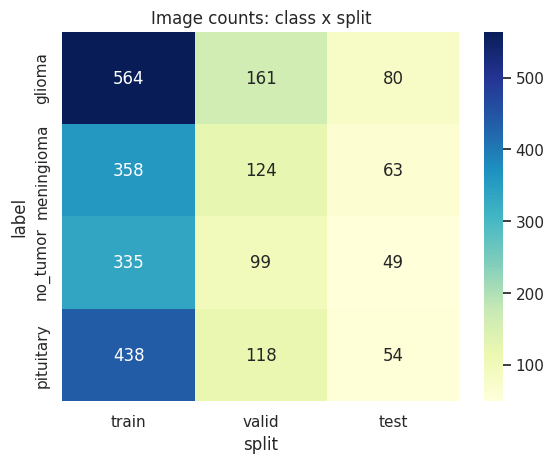

In [33]:
# Chart - 10 visualization code
ct = pd.crosstab(df['label'], df['split'])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu'); plt.title('Image counts: class x split'); plt.show()

##### 1. Why did you pick the specific chart?
A heatmap gives the exact count grid and makes small cells (e.g. 49 test no_tumor images) easy to spot.

##### 2. What is/are the insight(s) found from the chart?
The test set is small (246 images; only 49 no_tumor and 54 pituitary).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
A small test set gives wide confidence intervals: one wrong no_tumor prediction moves its recall by about 2 points. I will report confidence intervals/per-class counts and avoid over-interpreting small differences between models.

#### Chart - 11 - Possible leakage between splits

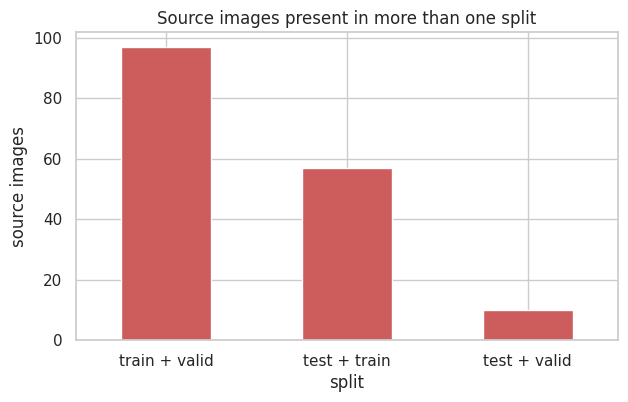

164 cross-split pairs; median correlation = 0.88


In [34]:
# Chart - 11 visualization code
leak = (df[df.cross_split_source].groupby('source_id')['split'].apply(lambda s: ' + '.join(sorted(set(s.astype(str))))).value_counts())
ax = leak.plot(kind='bar', figsize=(7, 4), color='indianred')
ax.set_ylabel('source images'); ax.set_title('Source images present in more than one split'); plt.xticks(rotation=0); plt.show()

# How similar are the copies? (correlation of 32x32 grey thumbnails)
def vec(p):
    a = np.asarray(Image.open(p).convert('L').resize((32, 32)), float); return ((a - a.mean()) / (a.std() + 1e-6)).ravel()
corrs = []
for sid, g in df[df.cross_split_source].groupby('source_id'):
    a = g.drop_duplicates('split')['path'].values[:2]
    corrs.append(np.corrcoef(vec(a[0]), vec(a[1]))[0, 1])
print(f"{len(corrs)} cross-split pairs; median correlation = {np.median(corrs):.2f}")

##### 1. Why did you pick the specific chart?
A bar chart of split combinations shows how many source images leak and where; the correlation printout quantifies how similar the copies are.

##### 2. What is/are the insight(s) found from the chart?
164 source images appear in two splits (mostly train+valid and train+test), with a median pixel correlation of about 0.88 - these are mostly augmented versions of the same scan.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
Negative impact if ignored: test accuracy would be optimistic and could mislead stakeholders. For a medical product that is a real risk. Action: report the caveat, and for a rigorous estimate re-split by source_id (group split) before final model selection.

#### Chart - 12 - Non-black area (foreground) by class

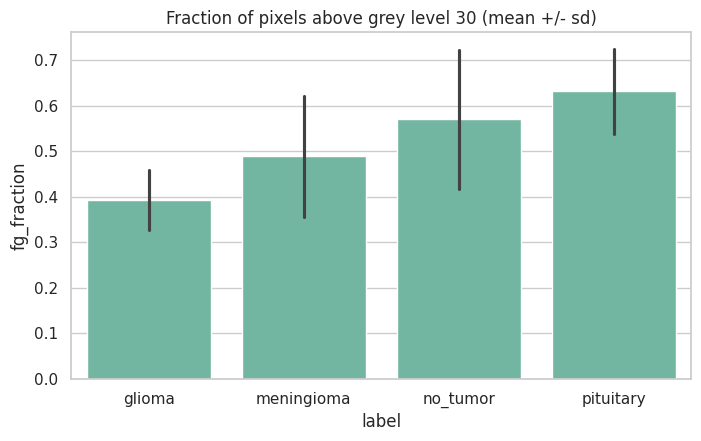

In [35]:
# Chart - 12 visualization code
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=df, x='label', y='fg_fraction', order=CLASS_NAMES, errorbar='sd', ax=ax)
ax.set_title('Fraction of pixels above grey level 30 (mean +/- sd)'); plt.show()

##### 1. Why did you pick the specific chart?
A bar chart with error bars summarises a derived feature per class with its variability.

##### 2. What is/are the insight(s) found from the chart?
Glioma images have the smallest non-black area (about 0.4), the other classes about 0.5-0.6, with no_tumor the most variable.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
Again shows classes differ in framing/brightness. Cropping to the brain or histogram normalisation is an optional preprocessing experiment, but heavy normalisation could also hide useful contrast, so I would test it empirically.

#### Chart - 13 - Brightness vs contrast scatter

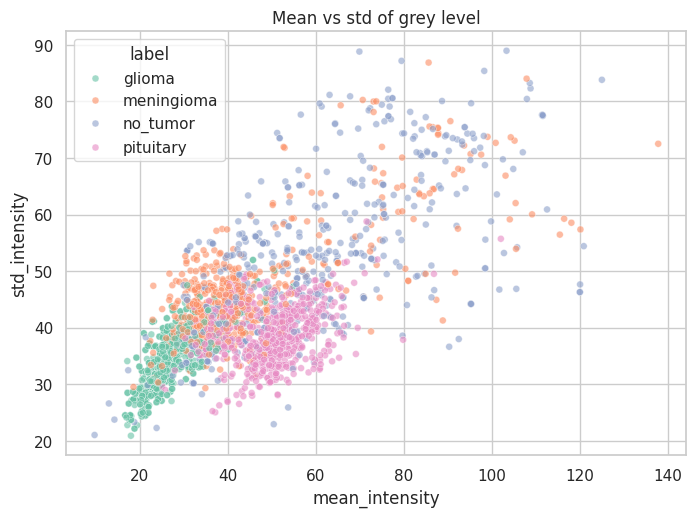

In [36]:
# Chart - 13 visualization code
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(data=df, x='mean_intensity', y='std_intensity', hue='label', hue_order=CLASS_NAMES, alpha=.6, s=25, ax=ax)
ax.set_title('Mean vs std of grey level'); plt.show()

##### 1. Why did you pick the specific chart?
A scatter plot shows two-feature class separability and clusters.

##### 2. What is/are the insight(s) found from the chart?
Glioma forms a compact cluster at low brightness/contrast; the other classes overlap heavily with each other along a broad diagonal.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.
Simple intensity statistics can separate glioma from the rest but not the other three classes, which is a useful baseline: a real model should beat this clearly. If it does not, it is probably learning brightness.

#### Chart - 14 - Correlation Heatmap

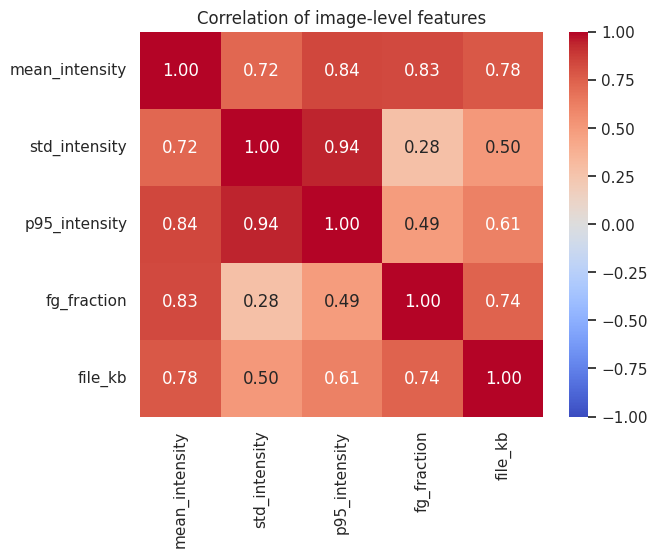

In [37]:
# Correlation Heatmap visualization code
num_cols = ['mean_intensity', 'std_intensity', 'p95_intensity', 'fg_fraction', 'file_kb']
plt.figure(figsize=(6.5, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of image-level features'); plt.show()

##### 1. Why did you pick the specific chart?
A correlation heatmap summarises pairwise linear relationships between all numeric features in one view.

##### 2. What is/are the insight(s) found from the chart?
Features are strongly inter-related: mean vs 95th-percentile intensity r = 0.84, mean vs foreground fraction r = 0.83, mean vs file size r = 0.78, std vs p95 r = 0.94. They largely measure one underlying thing - overall brightness - so they carry redundant information.

#### Chart - 15 - Pair Plot

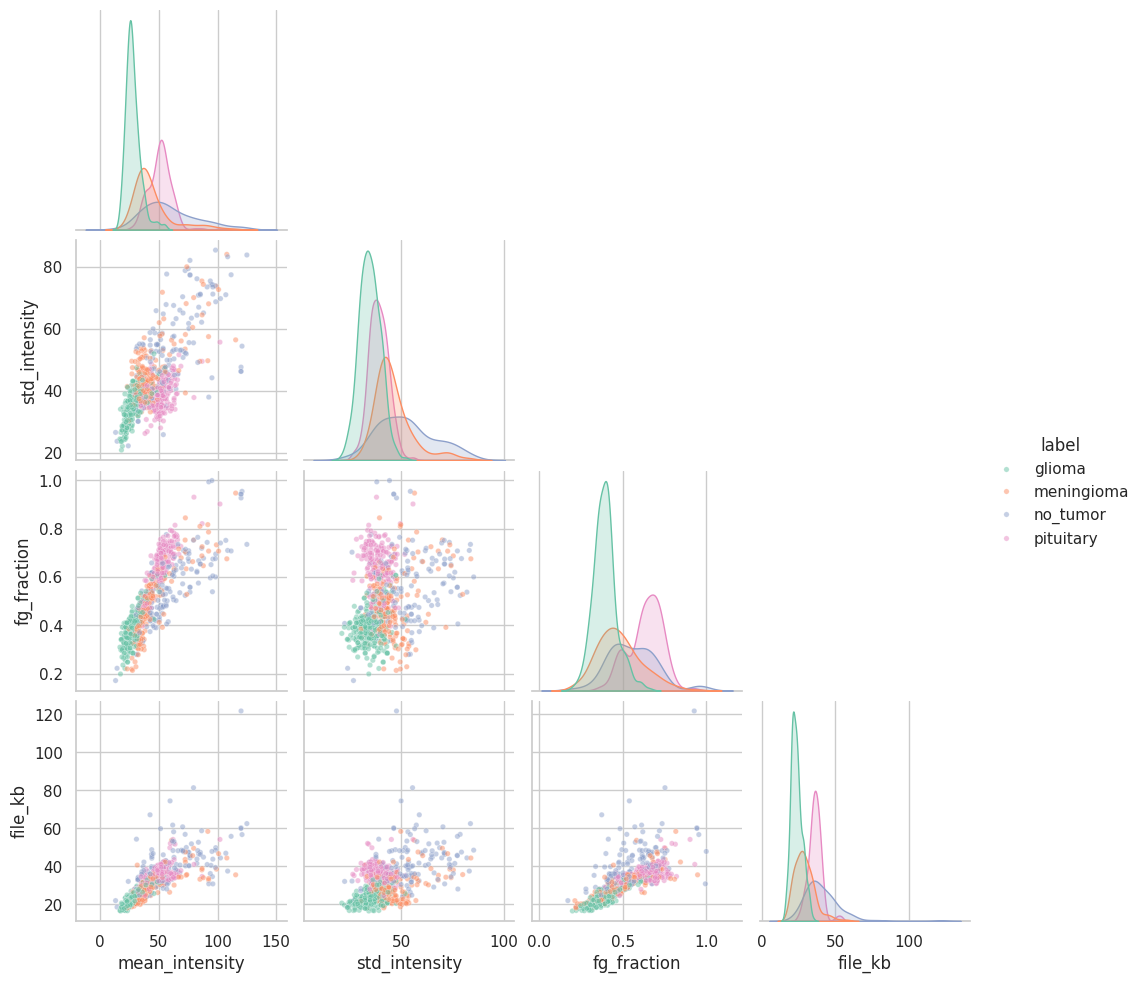

In [38]:
# Pair Plot visualization code
sample = df.sample(min(800, len(df)), random_state=SEED)
sns.pairplot(sample, vars=['mean_intensity', 'std_intensity', 'fg_fraction', 'file_kb'],
             hue='label', hue_order=CLASS_NAMES, corner=True, plot_kws=dict(alpha=.5, s=15))
plt.show()

##### 1. Why did you pick the specific chart?
A pair plot shows all pairwise scatter plots and each feature's per-class distribution in one figure.

##### 2. What is/are the insight(s) found from the chart?
Glioma separates cleanly from the other classes on most feature pairs, while meningioma, pituitary and no_tumor overlap substantially. Expect the hardest confusions among those three, which the confusion matrices should be checked against.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

1. **Preprocess**: resize to 224x224, scale per backbone, no cropping needed (uniform 640x640).
2. **Handle imbalance and shortcuts**: balanced class weights, macro-F1 reporting, and brightness/contrast/flip/rotation/zoom/shift augmentation.
3. **Fix the evaluation first**: re-split by `source_id` (or at minimum report the leakage caveat) so test metrics are trustworthy.
4. **Train and compare** a custom CNN and ResNet50, MobileNetV2, InceptionV3, EfficientNetB0 (head training, then fine-tuning at low LR), using EarlyStopping and ModelCheckpoint on validation loss.
5. **Select for deployment** on recall of tumour classes first, then macro-F1, model size and latency; MobileNetV2/EfficientNetB0 are likely candidates for cheap serving.
6. **Deploy responsibly** in Streamlit with confidence scores, a low-confidence warning and a clear 'decision support, not diagnosis' notice; validate on external data before any clinical use.

# **Conclusion**

The dataset is clean and uniform (2,443 images, 640x640 RGB, four classes) and suitable for CNN and transfer-learning approaches. The main risks are not data quality but **dataset bias**: strong brightness/file-size differences between classes and **near-duplicate images across splits**. Addressing these through augmentation, class weighting, per-class metrics and a source-aware split will make the later model comparison credible. The next steps are training and evaluating the models (`src/train.py`, `src/evaluate.py`) and serving the best one via `app.py`.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***